<a href="https://colab.research.google.com/github/ylperdomo/Calculo-Numerico/blob/Atividade-CN/Anima%C3%A7%C3%A3o_Gauss.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Animação da eliminação de Gauss

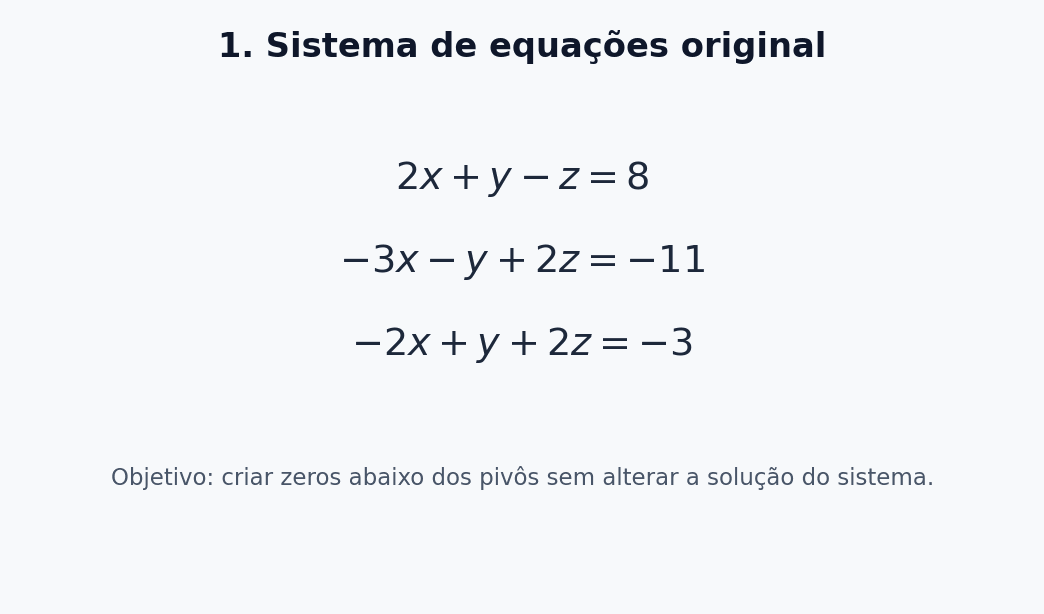

GIF salvo como: eliminacao_gauss_animada.gif (22 quadros)


In [1]:
from io import BytesIO
from copy import deepcopy
import matplotlib.pyplot as plt
from PIL import Image as PILImage
try:
    from IPython.display import Image as NotebookImage, display
except ImportError:
    NotebookImage = None

# Valores escritos como strings para manter as frações exatas no GIF
M0 = [[r'$2$', r'$1$', r'$-1$', r'$8$'],
      [r'$-3$', r'$-1$', r'$2$', r'$-11$'],
      [r'$-2$', r'$1$', r'$2$', r'$-3$']]

def trocar_linha(matriz, indice, nova_linha):
    resultado = deepcopy(matriz)
    resultado[indice] = nova_linha
    return resultado

# Estados intermediários: cada novo número aparece somente após seu cálculo
M21x = trocar_linha(M0, 1, [r'$0$', r'$-1$', r'$2$', r'$-11$'])
M21y = trocar_linha(M0, 1, [r'$0$', r'$\frac{1}{2}$', r'$2$', r'$-11$'])
M21z = trocar_linha(M0, 1, [r'$0$', r'$\frac{1}{2}$', r'$\frac{1}{2}$', r'$-11$'])
M1 = trocar_linha(M0, 1, [r'$0$', r'$\frac{1}{2}$', r'$\frac{1}{2}$', r'$1$'])
M31x = trocar_linha(M1, 2, [r'$0$', r'$1$', r'$2$', r'$-3$'])
M31y = trocar_linha(M1, 2, [r'$0$', r'$2$', r'$2$', r'$-3$'])
M31z = trocar_linha(M1, 2, [r'$0$', r'$2$', r'$1$', r'$-3$'])
M2 = trocar_linha(M1, 2, [r'$0$', r'$2$', r'$1$', r'$5$'])
M32x = trocar_linha(M2, 2, [r'$0$', r'$2$', r'$1$', r'$5$'])
M32y = trocar_linha(M2, 2, [r'$0$', r'$0$', r'$1$', r'$5$'])
M32z = trocar_linha(M2, 2, [r'$0$', r'$0$', r'$-1$', r'$5$'])
M3 = trocar_linha(M2, 2, [r'$0$', r'$0$', r'$-1$', r'$1$'])

r2_calculos = [
    r'$x:\;-3+\frac{3}{2}(2)=-3+3=0$',
    r'$y:\;-1+\frac{3}{2}(1)=-1+\frac{3}{2}=\frac{1}{2}$',
    r'$z:\;2+\frac{3}{2}(-1)=2-\frac{3}{2}=\frac{1}{2}$',
    r'$b:\;-11+\frac{3}{2}(8)=-11+12=1$'
]
r3_primeiro_calculos = [
    r'$x:\;-2+1(2)=0$',
    r'$y:\;1+1(1)=2$',
    r'$z:\;2+1(-1)=1$',
    r'$b:\;-3+1(8)=5$'
]
r3_segundo_calculos = [
    r'$x:\;0-4(0)=0$',
    r'$y:\;2-4\left(\frac{1}{2}\right)=2-2=0$',
    r'$z:\;1-4\left(\frac{1}{2}\right)=1-2=-1$',
    r'$b:\;5-4(1)=1$'
]

quadros = [
    dict(tipo='sistema', titulo='1. Sistema de equações original'),
    dict(tipo='coeficientes', titulo='2. Organizando coeficientes e termos independentes'),
    dict(tipo='matriz', titulo='3. Matriz aumentada inicial', matriz=M0,
         texto=r'Cada linha representa uma equação; a última coluna contém os termos independentes.'),
    dict(tipo='matriz', titulo='4. Primeiro pivô', matriz=M0,
         texto=r'O pivô é $a_{11}=2$. Devemos zerar os elementos $-3$ e $-2$ abaixo dele.',
         pivo=(0, 0), alvos=[(1, 0), (2, 0)]),
    dict(tipo='matriz', titulo='5. Multiplicador para eliminar o −3', matriz=M0,
         texto=r'$m_{21}=\frac{a_{21}}{a_{11}}=\frac{-3}{2}=-\frac{3}{2}$, então $R_2\leftarrow R_2-m_{21}R_1=R_2+\frac{3}{2}R_1$.',
         pivo=(0, 0), linha_pivo=0, linha_alterada=1),
    dict(tipo='matriz', titulo='6. Nova linha 2 — coeficiente de x', matriz=M21x,
         texto=r'$R_2\leftarrow R_2+\frac{3}{2}R_1$', calculos=r2_calculos[:1],
         pivo=(0, 0), linha_pivo=0, linha_alterada=1, calculadas=[(1, 0)]),
    dict(tipo='matriz', titulo='7. Nova linha 2 — coeficiente de y', matriz=M21y,
         texto=r'$R_2\leftarrow R_2+\frac{3}{2}R_1$', calculos=r2_calculos[:2],
         pivo=(0, 0), linha_pivo=0, linha_alterada=1, calculadas=[(1, 0), (1, 1)]),
    dict(tipo='matriz', titulo='8. Nova linha 2 — coeficiente de z', matriz=M21z,
         texto=r'$R_2\leftarrow R_2+\frac{3}{2}R_1$', calculos=r2_calculos[:3],
         pivo=(0, 0), linha_pivo=0, linha_alterada=1, calculadas=[(1, 0), (1, 1), (1, 2)]),
    dict(tipo='matriz', titulo='9. Nova linha 2 — termo independente', matriz=M1,
         texto=r'$R_2\leftarrow R_2+\frac{3}{2}R_1$', calculos=r2_calculos,
         pivo=(0, 0), linha_pivo=0, linha_alterada=1, calculadas=[(1, j) for j in range(4)]),
    dict(tipo='matriz', titulo='10. Multiplicador para eliminar o −2', matriz=M1,
         texto=r'$m_{31}=\frac{a_{31}}{a_{11}}=\frac{-2}{2}=-1$, então $R_3\leftarrow R_3-m_{31}R_1=R_3+R_1$.',
         pivo=(0, 0), linha_pivo=0, linha_alterada=2),
    dict(tipo='matriz', titulo='11. Nova linha 3 — coeficiente de x', matriz=M31x,
         texto=r'$R_3\leftarrow R_3+R_1$', calculos=r3_primeiro_calculos[:1],
         pivo=(0, 0), linha_pivo=0, linha_alterada=2, calculadas=[(2, 0)]),
    dict(tipo='matriz', titulo='12. Nova linha 3 — coeficiente de y', matriz=M31y,
         texto=r'$R_3\leftarrow R_3+R_1$', calculos=r3_primeiro_calculos[:2],
         pivo=(0, 0), linha_pivo=0, linha_alterada=2, calculadas=[(2, 0), (2, 1)]),
    dict(tipo='matriz', titulo='13. Nova linha 3 — coeficiente de z', matriz=M31z,
         texto=r'$R_3\leftarrow R_3+R_1$', calculos=r3_primeiro_calculos[:3],
         pivo=(0, 0), linha_pivo=0, linha_alterada=2, calculadas=[(2, 0), (2, 1), (2, 2)]),
    dict(tipo='matriz', titulo='14. Nova linha 3 — termo independente', matriz=M2,
         texto=r'$R_3\leftarrow R_3+R_1$', calculos=r3_primeiro_calculos,
         pivo=(0, 0), linha_pivo=0, linha_alterada=2, calculadas=[(2, j) for j in range(4)]),
    dict(tipo='matriz', titulo='15. Primeira coluna eliminada', matriz=M2,
         texto=r'Abaixo do primeiro pivô agora há dois zeros.', pivo=(0, 0),
         calculadas=[(1, 0), (2, 0)]),
    dict(tipo='matriz', titulo='16. Segundo pivô', matriz=M2,
         texto=r'O pivô é $a_{22}=\frac{1}{2}$. Devemos zerar o elemento $2$ abaixo dele.',
         pivo=(1, 1), alvos=[(2, 1)]),
    dict(tipo='matriz', titulo='17. Multiplicador para eliminar o 2', matriz=M2,
         texto=r'$m_{32}=\frac{a_{32}}{a_{22}}=\frac{2}{1/2}=4$, então $R_3\leftarrow R_3-4R_2$.',
         pivo=(1, 1), linha_pivo=1, linha_alterada=2),
    dict(tipo='matriz', titulo='18. Nova linha 3 — coeficiente de x', matriz=M32x,
         texto=r'$R_3\leftarrow R_3-4R_2$', calculos=r3_segundo_calculos[:1],
         pivo=(1, 1), linha_pivo=1, linha_alterada=2, calculadas=[(2, 0)]),
    dict(tipo='matriz', titulo='19. Nova linha 3 — coeficiente de y', matriz=M32y,
         texto=r'$R_3\leftarrow R_3-4R_2$', calculos=r3_segundo_calculos[:2],
         pivo=(1, 1), linha_pivo=1, linha_alterada=2, calculadas=[(2, 0), (2, 1)]),
    dict(tipo='matriz', titulo='20. Nova linha 3 — coeficiente de z', matriz=M32z,
         texto=r'$R_3\leftarrow R_3-4R_2$', calculos=r3_segundo_calculos[:3],
         pivo=(1, 1), linha_pivo=1, linha_alterada=2, calculadas=[(2, 0), (2, 1), (2, 2)]),
    dict(tipo='matriz', titulo='21. Nova linha 3 — termo independente', matriz=M3,
         texto=r'$R_3\leftarrow R_3-4R_2$', calculos=r3_segundo_calculos,
         pivo=(1, 1), linha_pivo=1, linha_alterada=2, calculadas=[(2, j) for j in range(4)]),
    dict(tipo='matriz', titulo='22. Eliminação de Gauss concluída', matriz=M3,
         texto='Todos os elementos abaixo da diagonal principal são zero: obtivemos a forma triangular superior.',
         calculadas=[(1, 0), (2, 0), (2, 1)])
]

def estilo_base(titulo):
    fig, ax = plt.subplots(figsize=(12, 7), dpi=110)
    fig.patch.set_facecolor('#f8fafc')
    ax.set_facecolor('#f8fafc')
    ax.axis('off')
    ax.text(0.5, 0.94, titulo, ha='center', va='center', fontsize=22,
            fontweight='bold', color='#0f172a', transform=ax.transAxes)
    return fig, ax

def desenhar_quadro(q):
    fig, ax = estilo_base(q['titulo'])
    if q['tipo'] == 'sistema':
        equacoes = [r'$2x+y-z=8$', r'$-3x-y+2z=-11$', r'$-2x+y+2z=-3$']
        for i, eq in enumerate(equacoes):
            ax.text(0.5, 0.70-i*0.14, eq, ha='center', fontsize=25,
                    color='#1e293b', transform=ax.transAxes)
        ax.text(0.5, 0.20, 'Objetivo: criar zeros abaixo dos pivôs sem alterar a solução do sistema.',
                ha='center', fontsize=15, color='#475569', transform=ax.transAxes)
        return fig

    if q['tipo'] == 'coeficientes':
        dados = [[r'$2$', r'$1$', r'$-1$', r'$8$'],
                 [r'$-3$', r'$-1$', r'$2$', r'$-11$'],
                 [r'$-2$', r'$1$', r'$2$', r'$-3$']]
        tabela = ax.table(cellText=dados, colLabels=[r'$x$', r'$y$', r'$z$', r'$b$'],
                          rowLabels=[r'$E_1$', r'$E_2$', r'$E_3$'], cellLoc='center',
                          bbox=[0.23, 0.29, 0.54, 0.47])
        tabela.auto_set_font_size(False); tabela.set_fontsize(20)
        for (i, j), c in tabela.get_celld().items():
            c.set_edgecolor('#94a3b8'); c.set_linewidth(1.2)
            c.set_facecolor('#dbeafe' if i == 0 else 'white')
        ax.text(0.5, 0.18, 'Os sinais acompanham cada coeficiente. A coluna b guarda os termos independentes.',
                ha='center', fontsize=14, color='#475569', transform=ax.transAxes)
        return fig

    ax.text(0.5, 0.84, q.get('texto', ''), ha='center', va='center',
            fontsize=14.5, color='#334155', transform=ax.transAxes)
    tabela = ax.table(cellText=q['matriz'], cellLoc='center',
                      colWidths=[0.13, 0.13, 0.13, 0.15], bbox=[0.08, 0.27, 0.40, 0.45])
    tabela.auto_set_font_size(False); tabela.set_fontsize(21)
    for c in tabela.get_celld().values():
        c.set_facecolor('white'); c.set_edgecolor('#94a3b8'); c.set_linewidth(1.2)
    x_barra = 0.08 + 0.40*(0.13+0.13+0.13)/(0.13+0.13+0.13+0.15)
    ax.plot([x_barra, x_barra], [0.27, 0.72], color='#334155', linewidth=2.6,
            transform=ax.transAxes, clip_on=False)
    if 'linha_pivo' in q:
        for j in range(4): tabela[(q['linha_pivo'], j)].set_facecolor('#dbeafe')
    if 'linha_alterada' in q:
        for j in range(4): tabela[(q['linha_alterada'], j)].set_facecolor('#ffedd5')
    for celula in q.get('alvos', []): tabela[celula].set_facecolor('#fecaca')
    for celula in q.get('calculadas', []): tabela[celula].set_facecolor('#bbf7d0')
    if 'pivo' in q:
        tabela[q['pivo']].set_facecolor('#fde68a')
        tabela[q['pivo']].set_text_props(fontweight='bold')
    calculos = q.get('calculos', [])
    if calculos:
        ax.text(0.58, 0.69, 'Cálculo de cada entrada:', fontsize=15, fontweight='bold',
                color='#0f172a', transform=ax.transAxes)
        for i, linha in enumerate(calculos):
            ax.text(0.58, 0.59-i*0.105, linha, fontsize=16, color='#1e293b', transform=ax.transAxes)
    else:
        ax.text(0.59, 0.49, r'$[A\mid b]$', fontsize=27, color='#64748b', transform=ax.transAxes)
    ax.text(0.5, 0.10, 'amarelo: pivô  •  azul: linha do pivô  •  laranja: linha alterada  •  verde: entrada já calculada',
            ha='center', fontsize=10.5, color='#64748b', transform=ax.transAxes)
    return fig

imagens = []
for quadro in quadros:
    figura = desenhar_quadro(quadro)
    buffer = BytesIO()
    figura.savefig(buffer, format='png', bbox_inches='tight', facecolor=figura.get_facecolor())
    plt.close(figura); buffer.seek(0)
    imagens.append(PILImage.open(buffer).convert('P', palette=PILImage.Palette.ADAPTIVE))

arquivo_gif = 'eliminacao_gauss_animada.gif'
duracoes = [2600, 3000, 2600, 2600, 3200] + [2300]*4 + [3200] + [2300]*4 + [2600, 2600, 3200] + [2300]*4 + [3500]
imagens[0].save(arquivo_gif, save_all=True, append_images=imagens[1:],
                 duration=duracoes, loop=0, optimize=False, disposal=2)
if NotebookImage is not None:
    display(NotebookImage(filename=arquivo_gif))
print(f'GIF salvo como: {arquivo_gif} ({len(imagens)} quadros)')